<a href="https://colab.research.google.com/github/EmperorBlackMD/BME-6720/blob/main/BME6720_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Week 1: MSD Spleen Dataset Initial Check
import os
import json
import pandas as pd
import tarfile
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Setting dataset path
tar_path = Path('/content/drive/MyDrive/BME6720_Project/Task09_Spleen.tar')
DATASET_DIR = Path('/content/drive/MyDrive/BME6720_Project/')

with tarfile.open(tar_path, 'r') as tar:
    tar.extractall(path=DATASET_DIR)
print('Extraction complete')

for root, dirs, files in os.walk(DATASET_DIR):
    print(root)


/tmp/ipykernel_2292/1469869667.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATASET_DIR)


Extraction complete
/content/drive/MyDrive/BME6720_Project
/content/drive/MyDrive/BME6720_Project/Task09_Spleen
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/labelsTr
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/imagesTr
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/imagesTs


In [ ]:
# Finalizing dataset path

DATASET_DIR1 = Path('/content/drive/MyDrive/BME6720_Project/Task09_Spleen')

imagesTr_dir = DATASET_DIR1 / 'imagesTr'
labelsTr_dir = DATASET_DIR1 / 'labelsTr'
imagesTs_dir = DATASET_DIR1 / 'imagesTs'
dataset_json_path = DATASET_DIR1 / 'dataset.json'

expected_paths = {
    'Dataset root': DATASET_DIR1,
    'Training images folder': imagesTr_dir,
    'Training labels folder': labelsTr_dir,
    'Test images folder': imagesTs_dir,
    'Dataset JSON': dataset_json_path
}

print('Dataset structure check')
for name, path in expected_paths.items():
    print(f'{name}: {'FOUND' if path.exists() else 'NOT FOUND'} --> {path}')

Dataset structure check
Dataset root: FOUND --> /content/drive/MyDrive/BME6720_Project/Task09_Spleen
Training images folder: FOUND --> /content/drive/MyDrive/BME6720_Project/Task09_Spleen/imagesTr
Training labels folder: FOUND --> /content/drive/MyDrive/BME6720_Project/Task09_Spleen/labelsTr
Test images folder: FOUND --> /content/drive/MyDrive/BME6720_Project/Task09_Spleen/imagesTs
Dataset JSON: FOUND --> /content/drive/MyDrive/BME6720_Project/Task09_Spleen/dataset.json


In [ ]:
# List image and label files
train_images = sorted(list(imagesTr_dir.glob('*.nii.gz')))
train_labels = sorted(list(labelsTr_dir.glob('*.nii.gz')))
test_images = sorted(list(imagesTs_dir.glob('*.nii.gz')))

print(f'Number of Training images: {len(train_images)}')
print(f'Number of Training labels: {len(train_labels)}')
print(f'Number of Test images: {len(test_images)}')

print('\nFirst 5 Training images:')
for image in train_images[:5]:
    print(image)

print('\nFirst 5 Training labels:')
for label in train_labels[:5]:
    print(label)


Number of Training images: 82
Number of Training labels: 82
Number of Test images: 40

First 5 Training images:
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/imagesTr/._spleen_10.nii.gz
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/imagesTr/._spleen_12.nii.gz
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/imagesTr/._spleen_13.nii.gz
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/imagesTr/._spleen_14.nii.gz
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/imagesTr/._spleen_16.nii.gz

First 5 Training labels:
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/labelsTr/._spleen_10.nii.gz
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/labelsTr/._spleen_12.nii.gz
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/labelsTr/._spleen_13.nii.gz
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/labelsTr/._spleen_14.nii.gz
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/labelsTr/._spleen_16.nii.gz


In [ ]:
# Read dataset.json metadata
with open(dataset_json_path, 'r') as f:
    dataset_json = json.load(f)

print('Dataset metadata:')
print(json.dumps(dataset_json, indent=4))


Dataset metadata:
{
    "name": "Spleen",
    "description": "Spleen Segmentation",
    "reference": "Memorial Sloan Kettering Cancer Center",
    "licence": "CC-BY-SA 4.0",
    "release": "1.0 06/08/2018",
    "tensorImageSize": "3D",
    "modality": {
        "0": "CT"
    },
    "labels": {
        "0": "background",
        "1": "spleen"
    },
    "numTraining": 41,
    "numTest": 20,
    "training": [
        {
            "image": "./imagesTr/spleen_19.nii.gz",
            "label": "./labelsTr/spleen_19.nii.gz"
        },
        {
            "image": "./imagesTr/spleen_31.nii.gz",
            "label": "./labelsTr/spleen_31.nii.gz"
        },
        {
            "image": "./imagesTr/spleen_52.nii.gz",
            "label": "./labelsTr/spleen_52.nii.gz"
        },
        {
            "image": "./imagesTr/spleen_40.nii.gz",
            "label": "./labelsTr/spleen_40.nii.gz"
        },
        {
            "image": "./imagesTr/spleen_3.nii.gz",
            "label": "./labelsTr

In [ ]:
# Creating case-level manifest

def get_case_id(filename):
    """
    Extracts case ID from MSD-style filenames.
    Example: spleen_10.nii.gz -> spleen_10
    """
    return filename.replace('.nii.gz', '')

image_case_ids = [get_case_id(image.name) for image in train_images]
label_case_ids = [get_case_id(label.name) for label in train_labels]
manifest = []

for image_file in train_images:
    case_id = get_case_id(image_file.name)
    expected_label = labelsTr_dir / image_file.name

    manifest.append({
        'case_id': case_id,
        'image_file': str(image_file),
        'label_file': str(expected_label),
        'label_exists': expected_label.exists()
    })
manifest_df = pd.DataFrame(manifest)
manifest_df.head()

,case_id,image_file,label_file,label_exists
0,._spleen_10,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True
1,._spleen_12,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True
2,._spleen_13,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True
3,._spleen_14,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True
4,._spleen_16,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True


In [ ]:
from IPython.core.interactiveshell import dis
# Check for missing labels or unmatched files
missing_labels = manifest_df[manifest_df['label_exists'] == False]

print(f'Total image-label pairs expected: {len(manifest_df)}')
print(f'Total missing label files: {len(missing_labels)}')

if len(missing_labels) > 0:
    display(missing_labels)
else:
    print('All training images have corresponding labels')


Total image-label pairs expected: 82
Total missing label files: 0
All training images have corresponding labels


In [ ]:
# Saving manifest for future weekly updates
output_manifest_path = DATASET_DIR1 / 'week1dataset_manifest.csv'
manifest_df.to_csv(output_manifest_path, index=False)
print(f'Manifest saved to {output_manifest_path}')

Manifest saved to /content/drive/MyDrive/BME6720_Project/Task09_Spleen/week1dataset_manifest.csv


# Week 3

In [ ]:
!pip install nibabel pandas numpy tqdm -q

In [ ]:
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Uploading the dataset path
DATASET_DIR = Path('/content/drive/MyDrive/BME6720_Project/Task09_Spleen')
manifest_path = DATASET_DIR / 'week1dataset_manifest.csv'
print('Dataset directory exists:', DATASET_DIR.exists())
print('Manifest exists:', manifest_path.exists())

Dataset directory exists: True
Manifest exists: True


In [ ]:
# Reloading saved manifest
manifest_df = pd.read_csv(manifest_path)
print('Manifest shape:', manifest_df.shape)
manifest_df.head()

Manifest shape: (82, 4)


,case_id,image_file,label_file,label_exists
0,._spleen_10,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True
1,._spleen_12,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True
2,._spleen_13,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True
3,._spleen_14,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True
4,._spleen_16,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True


In [ ]:
#Manifest cleanup
import os
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file.startswith('._'):
            os.remove(os.path.join(root, file))
print('Removed unnecessary metadata files')

Removed unnecessary metadata files


In [ ]:
len(manifest_df)

82

In [ ]:
# Confirming if files are still all accessible and cleaning the data
manifest_df['image_exists'] = manifest_df['image_file'].apply(lambda x: Path(x).exists())
manifest_df['label_exists'] = manifest_df['label_file'].apply(lambda x: Path(x).exists())

clean_manifest_df = manifest_df[
    (manifest_df['image_exists'] == True) &
    (manifest_df['label_exists'] == True)
].copy()

print('Original manifest rows:', len(manifest_df))
print('Cleaned manifest rows:', len(clean_manifest_df))

clean_manifest_df.head()

Original manifest rows: 82
Cleaned manifest rows: 41


,case_id,image_file,label_file,label_exists,image_exists
41,spleen_10,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
42,spleen_12,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
43,spleen_13,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
44,spleen_14,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
45,spleen_16,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True


In [ ]:
# Saving cleaned manifest
clean_manifest_path = DATASET_DIR / 'week3dataset_manifest_clean.csv'
clean_manifest_df.to_csv(clean_manifest_path, index=False)
print('Cleaned manifest saved to:', clean_manifest_path)

Cleaned manifest saved to: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/week3dataset_manifest_clean.csv


In [ ]:
# Reloading cleaned manifest
manifest_df = pd.read_csv(clean_manifest_path)
print('Manifest shape:', manifest_df.shape)
manifest_df.head()

Manifest shape: (41, 5)


,case_id,image_file,label_file,label_exists,image_exists
0,spleen_10,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
1,spleen_12,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
2,spleen_13,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
3,spleen_14,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
4,spleen_16,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True


In [ ]:
# Inspecting a sigle case
sample_row = manifest_df.iloc[0]
image_path = sample_row['image_file']
label_path = sample_row['label_file']

image_nii = nib.load(image_path)
label_nii = nib.load(label_path)

image_data = image_nii.get_fdata()
label_data = label_nii.get_fdata()

print('Case ID:', sample_row['case_id'])
print('Image shape:', image_data.shape)
print('Label shape:', label_data.shape)
print('Voxel spacing:', image_nii.header.get_zooms()[:3])
print('Unique label values:', np.unique(label_data))

Case ID: spleen_10
Image shape: (512, 512, 55)
Label shape: (512, 512, 55)
Voxel spacing: (np.float32(0.976562), np.float32(0.976562), np.float32(5.0))
Unique label values: [0. 1.]


In [ ]:
# Extracting image shape and spacing for all cases
summary_rows = []
for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df)):
    case_id = row['case_id']
    image_path = Path(row['image_file'])
    label_path = Path(row['label_file'])

    image_nii = nib.load(image_path)
    label_nii = nib.load(label_path)

    image_shape = image_nii.shape
    label_shape = label_nii.shape
    image_spacing = image_nii.header.get_zooms()[:3]

    summary_rows.append({
        'case_id': case_id,
        'image_dim_x': image_shape[0],
        'image_dim_y': image_shape[1],
        'image_dim_z': image_shape[2],
        'label_dim_x': label_shape[0],
        'label_dim_y': label_shape[1],
        'label_dim_z': label_shape[2],
        'image_spacing_x_mm': image_spacing[0],
        'image_spacing_y_mm': image_spacing[1],
        'image_spacing_z_mm': image_spacing[2],

        'image_label_shape_match': image_shape == label_shape
    })
shape_spacing_df = pd.DataFrame(summary_rows)
shape_spacing_df.head()


100%|██████████| 41/41 [01:35<00:00,  2.32s/it]


,case_id,image_dim_x,image_dim_y,image_dim_z,label_dim_x,label_dim_y,label_dim_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,image_label_shape_match
0,spleen_10,512,512,55,512,512,55,0.976562,0.976562,5.0,True
1,spleen_12,512,512,168,512,512,168,0.753906,0.753906,1.5,True
2,spleen_13,512,512,77,512,512,77,0.742188,0.742188,2.5,True
3,spleen_14,512,512,54,512,512,54,0.851562,0.851562,5.0,True
4,spleen_16,512,512,61,512,512,61,0.792969,0.792969,8.0,True


In [ ]:
# Adding total voxel count and physical scan volume
shape_spacing_df['total_voxels'] = (shape_spacing_df['image_dim_x'] * shape_spacing_df['image_dim_y'] * shape_spacing_df['image_dim_z'])
shape_spacing_df['voxel_volume_mm3'] = (
    shape_spacing_df['image_spacing_x_mm'] *
    shape_spacing_df['image_spacing_y_mm'] *
    shape_spacing_df['image_spacing_z_mm']
)
shape_spacing_df['physical_scan_volume_mm3'] = (
    shape_spacing_df['total_voxels'] * shape_spacing_df['voxel_volume_mm3']
)
shape_spacing_df['scan_volume_liters'] = (shape_spacing_df['physical_scan_volume_mm3'] / 1_000_000)
shape_spacing_df.head()

,case_id,image_dim_x,image_dim_y,image_dim_z,label_dim_x,label_dim_y,label_dim_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,image_label_shape_match,total_voxels,voxel_volume_mm3,physical_scan_volume_mm3,scan_volume_liters
0,spleen_10,512,512,55,512,512,55,0.976562,0.976562,5.0,True,14417920,4.768367,6.874993e+07,68.749931
1,spleen_12,512,512,168,512,512,168,0.753906,0.753906,1.5,True,44040192,0.852561,3.754697e+07,37.546968
2,spleen_13,512,512,77,512,512,77,0.742188,0.742188,2.5,True,20185088,1.377108,2.779704e+07,27.797036
3,spleen_14,512,512,54,512,512,54,0.851562,0.851562,5.0,True,14155776,3.625789,5.132586e+07,51.325859
4,spleen_16,512,512,61,512,512,61,0.792969,0.792969,8.0,True,15990784,5.030398,8.044001e+07,80.440014


In [ ]:
# Generating summary statistics
shape_spacing_df.describe()

,image_dim_x,image_dim_y,image_dim_z,label_dim_x,label_dim_y,label_dim_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,total_voxels,voxel_volume_mm3,physical_scan_volume_mm3,scan_volume_liters
count,41.0,41.0,41.000000,41.0,41.0,41.000000,41.000000,41.000000,41.000000,4.100000e+01,41.000000,4.100000e+01,41.000000
mean,512.0,512.0,89.024390,512.0,512.0,89.024390,0.812405,0.812405,4.368292,2.333721e+07,2.876291,6.103546e+07,61.035463
std,0.0,0.0,36.752203,0.0,0.0,36.752203,0.097809,0.097809,1.552808,9.634369e+06,1.142730,2.502018e+07,25.020176
min,512.0,512.0,31.000000,512.0,512.0,31.000000,0.613281,0.613281,1.500000,8.126464e+06,0.852561,2.341653e+07,23.416532
25%,512.0,512.0,60.000000,512.0,512.0,60.000000,0.742188,0.742188,4.000000,1.572864e+07,2.096377,4.021944e+07,40.219442
50%,512.0,512.0,90.000000,512.0,512.0,90.000000,0.792969,0.792969,5.000000,2.359296e+07,2.827167,5.757799e+07,57.577994
75%,512.0,512.0,103.000000,512.0,512.0,103.000000,0.902344,0.902344,5.000000,2.700083e+07,3.693607,7.919217e+07,79.192175
max,512.0,512.0,168.000000,512.0,512.0,168.000000,0.976562,0.976562,8.000000,4.404019e+07,5.030398,1.109909e+08,110.990932


In [ ]:
shape_spacing_df[
    [
        'image_dim_x', 'image_dim_y', 'image_dim_z',
        'image_spacing_x_mm', 'image_spacing_y_mm', 'image_spacing_z_mm',
        'total_voxels', 'voxel_volume_mm3', 'physical_scan_volume_mm3'
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
image_dim_x,41.0,5.120000e+02,0.000000e+00,5.120000e+02,5.120000e+02,5.120000e+02,5.120000e+02,5.120000e+02
image_dim_y,41.0,5.120000e+02,0.000000e+00,5.120000e+02,5.120000e+02,5.120000e+02,5.120000e+02,5.120000e+02
image_dim_z,41.0,8.902439e+01,3.675220e+01,3.100000e+01,6.000000e+01,9.000000e+01,1.030000e+02,1.680000e+02
image_spacing_x_mm,41.0,8.124048e-01,9.780948e-02,6.132810e-01,7.421880e-01,7.929690e-01,9.023440e-01,9.765620e-01
image_spacing_y_mm,41.0,8.124048e-01,9.780948e-02,6.132810e-01,7.421880e-01,7.929690e-01,9.023440e-01,9.765620e-01
image_spacing_z_mm,41.0,4.368292e+00,1.552808e+00,1.500000e+00,4.000000e+00,5.000000e+00,5.000000e+00,8.000000e+00
total_voxels,41.0,2.333721e+07,9.634369e+06,8.126464e+06,1.572864e+07,2.359296e+07,2.700083e+07,4.404019e+07
voxel_volume_mm3,41.0,2.876291e+00,1.142730e+00,8.525614e-01,2.096377e+00,2.827167e+00,3.693607e+00,5.030398e+00
physical_scan_volume_mm3,41.0,6.103546e+07,2.502018e+07,2.341653e+07,4.021944e+07,5.757799e+07,7.919217e+07,1.109909e+08


In [ ]:
# Checking for problems
shape_mismatch_cases = shape_spacing_df[shape_spacing_df['image_label_shape_match'] == False]
print('Cases with mismatched image and label shapes:', len(shape_mismatch_cases))
shape_mismatch_cases

Cases with mismatched image and label shapes: 0


,case_id,image_dim_x,image_dim_y,image_dim_z,label_dim_x,label_dim_y,label_dim_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,image_label_shape_match,total_voxels,voxel_volume_mm3,physical_scan_volume_mm3,scan_volume_liters


In [ ]:
# Saving summary table
summary_table_path = DATASET_DIR / 'week3dataset_summary_table.csv'
shape_spacing_df.to_csv(summary_table_path, index=False)
print('Summary table saved to:', summary_table_path)

Summary table saved to: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/week3dataset_summary_table.csv


In [ ]:
# Display final table
shape_spacing_df.head(10)

,case_id,image_dim_x,image_dim_y,image_dim_z,label_dim_x,label_dim_y,label_dim_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,image_label_shape_match,total_voxels,voxel_volume_mm3,physical_scan_volume_mm3,scan_volume_liters
0,spleen_10,512,512,55,512,512,55,0.976562,0.976562,5.0,True,14417920,4.768367,6.874993e+07,68.749931
1,spleen_12,512,512,168,512,512,168,0.753906,0.753906,1.5,True,44040192,0.852561,3.754697e+07,37.546968
2,spleen_13,512,512,77,512,512,77,0.742188,0.742188,2.5,True,20185088,1.377108,2.779704e+07,27.797036
3,spleen_14,512,512,54,512,512,54,0.851562,0.851562,5.0,True,14155776,3.625789,5.132586e+07,51.325859
4,spleen_16,512,512,61,512,512,61,0.792969,0.792969,8.0,True,15990784,5.030398,8.044001e+07,80.440014
5,spleen_17,512,512,95,512,512,95,0.613281,0.613281,2.5,True,24903680,0.940284,2.341653e+07,23.416532
6,spleen_18,512,512,164,512,512,164,0.966797,0.966797,1.5,True,42991616,1.402045,6.027617e+07,60.276165
7,spleen_19,512,512,51,512,512,51,0.796875,0.796875,5.0,True,13369344,3.175049,4.244832e+07,42.448320
8,spleen_2,512,512,90,512,512,90,0.794922,0.794922,5.0,True,23592960,3.159505,7.454207e+07,74.542073
9,spleen_20,512,512,168,512,512,168,0.933594,0.933594,1.5,True,44040192,1.307397,5.757799e+07,57.577994


# WEEK 4

In [ ]:
# Reloading packages
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from numpy._core.fromnumeric import shape
# Defining Project Paths
DATASET_DIR = Path('/content/drive/MyDrive/BME6720_Project/Task09_Spleen')
manifest_path = DATASET_DIR / 'week3dataset_manifest_clean.csv'
shape_spacing_path = DATASET_DIR / 'week3dataset_summary_table.csv'

print('Dataset directory exists:', DATASET_DIR.exists())
print('Manifest exists:', manifest_path.exists())
print('Summary table exists:', shape_spacing_path.exists())

Dataset directory exists: True
Manifest exists: True
Summary table exists: True


In [ ]:
# Reloading saved manifest
manifest_df = pd.read_csv(manifest_path)
print('Manifest rows:', len(manifest_df))
manifest_df.head()

Manifest rows: 41


,case_id,image_file,label_file,label_exists,image_exists
0,spleen_10,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
1,spleen_12,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
2,spleen_13,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
3,spleen_14,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True
4,spleen_16,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True


In [ ]:
# Reload shape/spacing summary
shape_spacing_df = pd.read_csv(shape_spacing_path)
print('Summary table rows:', len(shape_spacing_df))
shape_spacing_df.head()

Summary table rows: 41


,case_id,image_dim_x,image_dim_y,image_dim_z,label_dim_x,label_dim_y,label_dim_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,image_label_shape_match,total_voxels,voxel_volume_mm3,physical_scan_volume_mm3,scan_volume_liters
0,spleen_10,512,512,55,512,512,55,0.976562,0.976562,5.0,True,14417920,4.768367,6.874993e+07,68.749931
1,spleen_12,512,512,168,512,512,168,0.753906,0.753906,1.5,True,44040192,0.852561,3.754697e+07,37.546968
2,spleen_13,512,512,77,512,512,77,0.742188,0.742188,2.5,True,20185088,1.377107,2.779704e+07,27.797036
3,spleen_14,512,512,54,512,512,54,0.851562,0.851562,5.0,True,14155776,3.625789,5.132586e+07,51.325859
4,spleen_16,512,512,61,512,512,61,0.792969,0.792969,8.0,True,15990784,5.030398,8.044001e+07,80.440014


In [ ]:
# Confirming the 2 tables align
print('Manifest cases:', manifest_df['case_id'].nunique())
print('Shape/spacing cases:', shape_spacing_df['case_id'].nunique())

missing_from_summary = set(manifest_df['case_id']) - set(shape_spacing_df['case_id'])
missing_from_manifest = set(shape_spacing_df['case_id']) - set(manifest_df['case_id'])

print('Cases missing from summary table:', missing_from_summary)
print('Cases missing from manifest:', missing_from_manifest)

Manifest cases: 41
Shape/spacing cases: 41
Cases missing from summary table: set()
Cases missing from manifest: set()


In [ ]:
# Merge saved tables
inspection_df = manifest_df.merge(shape_spacing_df, on='case_id', how= 'left')
print('Merged inspection table shape:', inspection_df.shape)
inspection_df.head()

Merged inspection table shape: (41, 19)


,case_id,image_file,label_file,label_exists,image_exists,image_dim_x,image_dim_y,image_dim_z,label_dim_x,label_dim_y,label_dim_z,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm,image_label_shape_match,total_voxels,voxel_volume_mm3,physical_scan_volume_mm3,scan_volume_liters
0,spleen_10,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,55,512,512,55,0.976562,0.976562,5.0,True,14417920,4.768367,6.874993e+07,68.749931
1,spleen_12,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,168,512,512,168,0.753906,0.753906,1.5,True,44040192,0.852561,3.754697e+07,37.546968
2,spleen_13,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,77,512,512,77,0.742188,0.742188,2.5,True,20185088,1.377107,2.779704e+07,27.797036
3,spleen_14,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,54,512,512,54,0.851562,0.851562,5.0,True,14155776,3.625789,5.132586e+07,51.325859
4,spleen_16,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,61,512,512,61,0.792969,0.792969,8.0,True,15990784,5.030398,8.044001e+07,80.440014


In [ ]:
# Reconfirming file accessibility
inspection_df['image_exists'] = inspection_df['image_file'].apply(lambda x: Path(x).exists())
inspection_df['label_exists'] = inspection_df['label_file'].apply(lambda x: Path(x).exists())

print('images available:', inspection_df['image_exists'].sum(), '/', len(inspection_df))
print('Labels available:', inspection_df['label_exists'].sum(), '/', len(inspection_df))

images available: 41 / 41
Labels available: 41 / 41


In [ ]:
# Saving merged inspection table
merged_output_path = DATASET_DIR / 'week4dataset_merged_inspection.csv'
inspection_df.to_csv(merged_output_path, index=False)
print('Merged inspection table saved to:', merged_output_path)


Merged inspection table saved to: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/week4dataset_merged_inspection.csv


In [ ]:
# Quick spacing review
spacing_cols = ['image_spacing_x_mm', 'image_spacing_y_mm', 'image_spacing_z_mm']
inspection_df[spacing_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
image_spacing_x_mm,41.0,0.812405,0.097809,0.613281,0.742188,0.792969,0.902344,0.976562
image_spacing_y_mm,41.0,0.812405,0.097809,0.613281,0.742188,0.792969,0.902344,0.976562
image_spacing_z_mm,41.0,4.368292,1.552808,1.500000,4.000000,5.000000,5.000000,8.000000


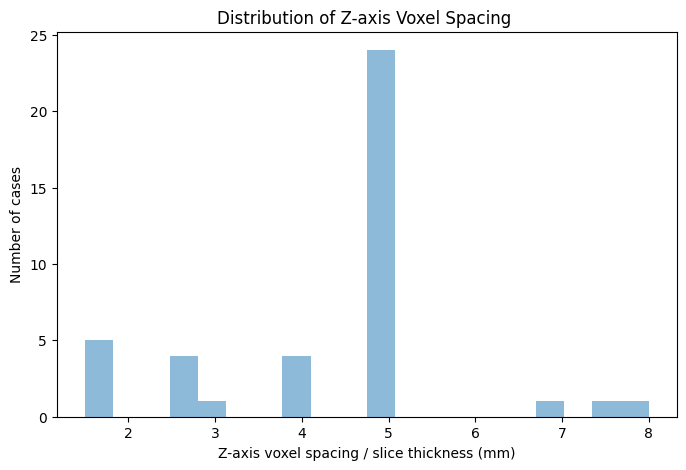

In [ ]:
# Visualize voxel spacing variability
plt.figure(figsize=(8,5))
plt.hist(inspection_df['image_spacing_z_mm'], bins=20, alpha=0.5)
plt.xlabel('Z-axis voxel spacing / slice thickness (mm)')
plt.ylabel('Number of cases')
plt.title('Distribution of Z-axis Voxel Spacing ')
plt.show()

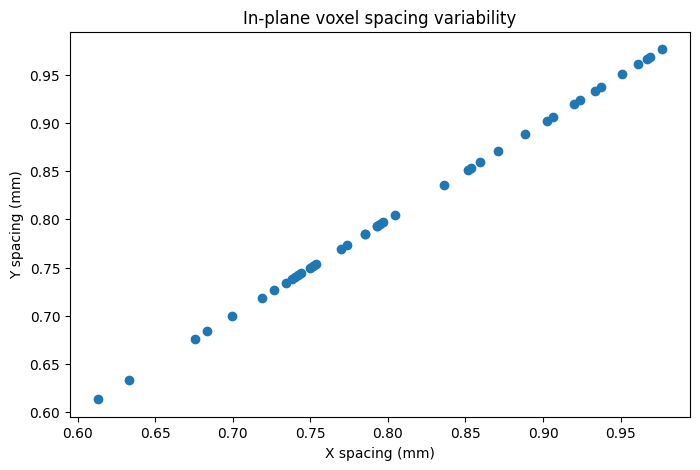

In [ ]:
# Visualize voxel spacing variability
plt.figure(figsize=(8,5))
plt.scatter(inspection_df['image_spacing_x_mm'], inspection_df['image_spacing_y_mm'])
plt.xlabel('X spacing (mm)')
plt.ylabel('Y spacing (mm)')
plt.title('In-plane voxel spacing variability')
plt.show()

In [ ]:
# Identify any outliers
inspection_df[
    ['case_id', 'image_spacing_x_mm', 'image_spacing_y_mm', 'image_spacing_z_mm']
].sort_values('image_spacing_z_mm').head()


,case_id,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm
1,spleen_12,0.753906,0.753906,1.50000
6,spleen_18,0.966797,0.966797,1.50000
11,spleen_22,0.968750,0.968750,1.50000
9,spleen_20,0.933594,0.933594,1.50000
34,spleen_6,0.919922,0.919922,1.60001


In [ ]:
inspection_df[
    ['case_id', 'image_spacing_x_mm', 'image_spacing_y_mm', 'image_spacing_z_mm']
].sort_values('image_spacing_z_mm', ascending=False).head()

,case_id,image_spacing_x_mm,image_spacing_y_mm,image_spacing_z_mm
4,spleen_16,0.792969,0.792969,8.00000
39,spleen_8,0.785156,0.785156,7.50000
32,spleen_56,0.699219,0.699219,6.99997
0,spleen_10,0.976562,0.976562,5.00000
3,spleen_14,0.851562,0.851562,5.00000


# WEEK 5

In [ ]:
# HU (intensity) Analysis .... Compute HU statistics per case
!pip install nibabel pandas numpy tqdm -q
!pip install tqdm -q

In [ ]:
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

hu_rows = []
for _, row in tqdm(inspection_df.iterrows(), total=len(inspection_df)):
    image_path = row['image_file']

    img = nib.load(image_path).get_fdata(dtype=np.float32)

    hu_rows.append({
        'case_id': row['case_id'],
        'min_hu': np.min(img),
        'max_hu': np.max(img),
        'mean_hu': np.mean(img),
        'std_hu': np.std(img),
        'p1_hu': np.percentile(img, 1),
        'p99_hu': np.percentile(img, 99)
    })
hu_df = pd.DataFrame(hu_rows)
hu_df.head()

100%|██████████| 41/41 [02:54<00:00,  4.25s/it]


,case_id,min_hu,max_hu,mean_hu,std_hu,p1_hu,p99_hu
0,spleen_10,-1024.0,3072.0,-450.261780,481.565002,-1024.0,270.0
1,spleen_12,-1024.0,3072.0,-568.890503,497.496002,-1024.0,258.0
2,spleen_13,-1024.0,1189.0,-464.471893,496.942780,-1024.0,297.0
3,spleen_14,-1024.0,1846.0,-481.528503,493.475708,-1024.0,242.0
4,spleen_16,-1024.0,1616.0,-471.438232,496.645447,-1024.0,400.0


In [ ]:
# Merge into inspection table
inspection_df = inspection_df.merge(hu_df, on='case_id', how='left')
inspection_df[['min_hu', 'max_hu', 'mean_hu', 'p1_hu', 'p99_hu']].describe()

,min_hu,max_hu,mean_hu,p1_hu,p99_hu
count,41.0,41.000000,41.000000,41.0,41.000000
mean,-1024.0,1914.219482,-530.105347,-1024.0,318.682922
std,0.0,695.902222,78.319710,0.0,79.919785
min,-1024.0,1166.000000,-726.595337,-1024.0,178.000000
25%,-1024.0,1369.000000,-568.890503,-1024.0,258.000000
50%,-1024.0,1616.000000,-520.836609,-1024.0,329.000000
75%,-1024.0,2258.000000,-474.227509,-1024.0,367.000000
max,-1024.0,3072.000000,-391.375549,-1024.0,521.000000


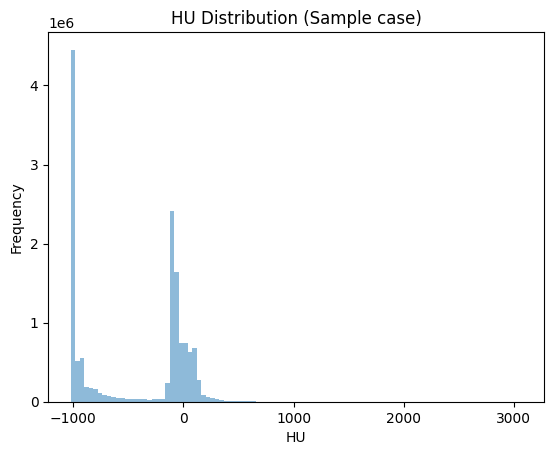

In [ ]:
# Plot histogram (sample case)
sample_case = inspection_df.iloc[0]['image_file']
img = nib.load(sample_case).get_fdata(dtype=np.float32)

plt.hist(img.flatten(), bins=100, alpha=0.5)
plt.title('HU Distribution (Sample case)')
plt.xlabel('HU')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Overly Mask on CT slice
def plot_overlay(image, label, slice_idx):
    plt.figure(figsize=(6, 6))
    plt.imshow(image[:, :, slice_idx], cmap='gray')
    plt.imshow(label[:, :, slice_idx], alpha=0.3, cmap='Reds')
    plt.title(f'Slice{slice_idx}')
    plt.axis('off')
    plt.show()

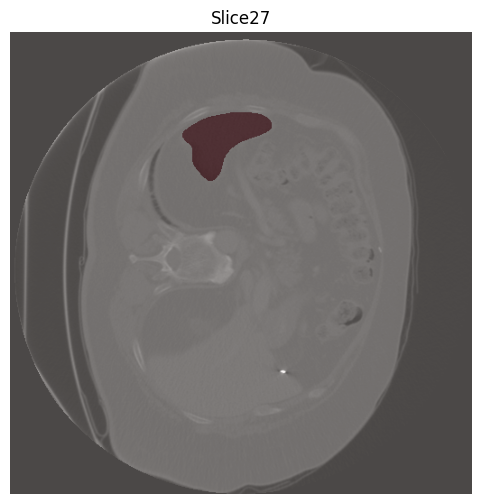

In [ ]:
# Testing on s ample case
row = inspection_df.iloc[0]
img = nib.load(row['image_file']).get_fdata(dtype=np.float32)
label = nib.load(row['label_file']).get_fdata(dtype=np.float32)

mid_slice = img.shape[2] // 2

plot_overlay(img, label, mid_slice)

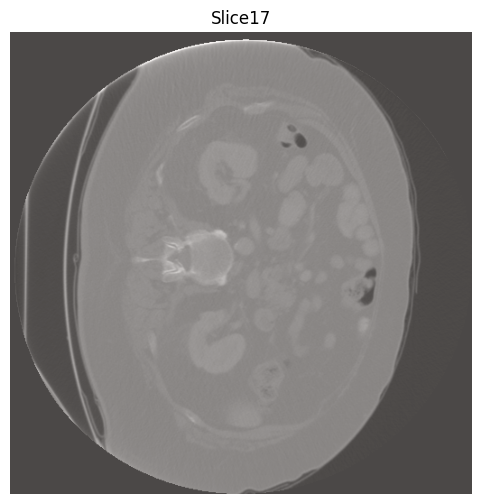

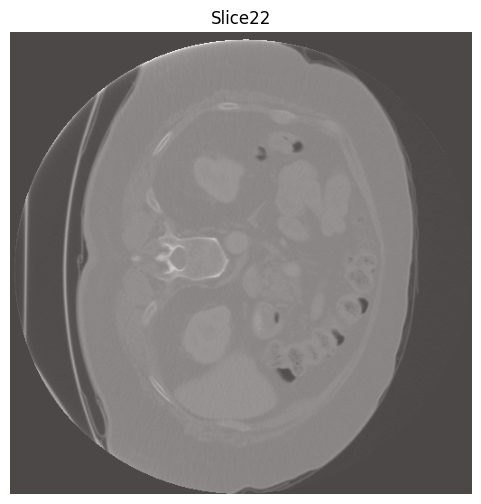

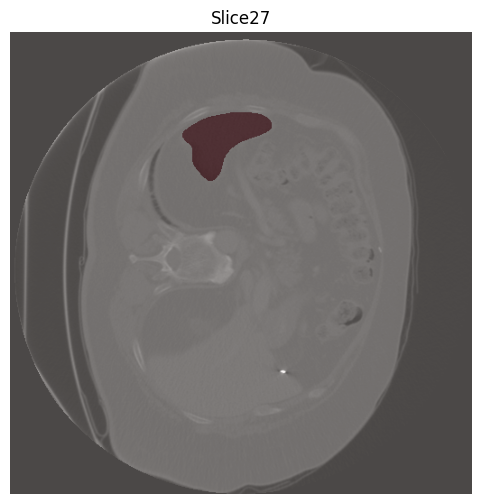

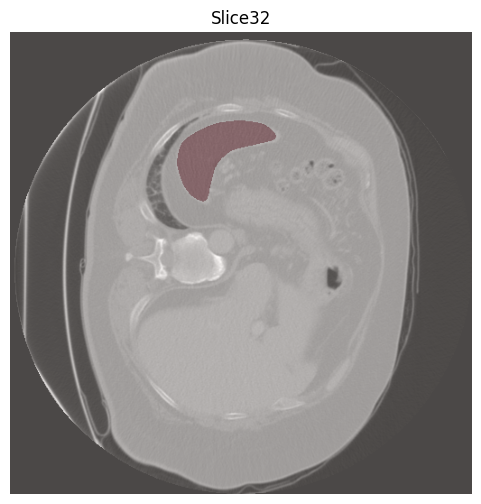

In [ ]:
# Visualizing multiple slices
for s in range(mid_slice-10, mid_slice+10, 5):
    plot_overlay(img, label, s)

In [ ]:
# Automatically find slices where mask exists
mask_slices = np.where(np.sum(label > 0, axis=(0, 1)) > 0)[0]

print('First slice with spleen:', mask_slices[0])
print('Last slice with spleen:', mask_slices[-1])
print('Number of slices with spleen:', len(mask_slices))
print('Slices with spleen:', mask_slices)

First slice with spleen: 23
Last slice with spleen: 39
Number of slices with spleen: 17
Slices with spleen: [23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


In [ ]:
# Class Imbalance Analysis
imbalance_rows = []

for _, row in tqdm(inspection_df.iterrows(), total=len(inspection_df)):
    label = nib.load(row['label_file']).get_fdata()

    total_voxels = label.size
    spleen_voxels = np.sum(label > 0)

    imbalance_rows.append({
        'case_id': row['case_id'],
        'spleen_voxels': spleen_voxels,
        'total_voxels': total_voxels,
        'spleen_fraction': spleen_voxels / total_voxels
    })
imbalance_df = pd.DataFrame(imbalance_rows)


100%|██████████| 41/41 [00:08<00:00,  4.88it/s]


In [ ]:
inspection_df = inspection_df.drop(
    columns=['spleen_voxels', 'total_voxels', 'spleen_fraction'],
    errors='ignore'
)
inspection_df = inspection_df.merge(
    imbalance_df, on='case_id', how='left'
)

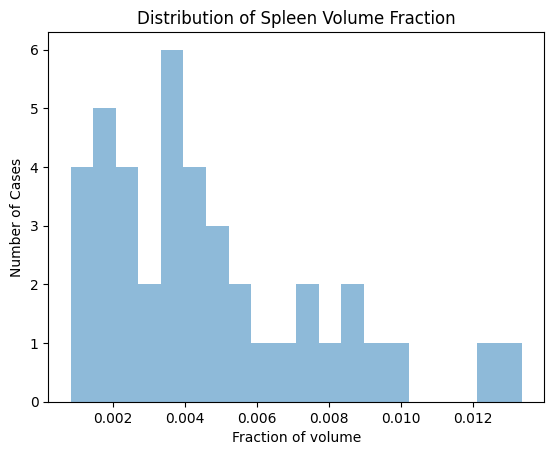

In [ ]:
# Plot distribution
plt.hist(inspection_df['spleen_fraction'], bins=20, alpha=0.5)
plt.axvline(inspection_df['spleen_fraction'].mean(), color='r', linestyle='dashed', linewidth=2)
plt.xlabel('Fraction of volume')
plt.ylabel('Number of Cases')
plt.title('Distribution of Spleen Volume Fraction')
plt.show()

In [ ]:
# Computing bounding box
def get_bbox(mask):
    coords = np.where(mask>0)

    x_min, x_max = coords[0].min(), coords[0].max()
    y_min, y_max = coords[1].min(), coords[1].max()
    z_min, z_max = coords[2].min(), coords[2].max()

    return (x_min, x_max, y_min, y_max, z_min, z_max)

In [ ]:
# Now applying it to all cases
bbox_rows = []
for _, row in tqdm(inspection_df.iterrows(), total=len(inspection_df)):
    label = nib.load(row['label_file']).get_fdata()

    x_min, x_max, y_min, y_max, z_min, z_max = get_bbox(label)

    bbox_rows.append({
        'case_id': row['case_id'],
        'bbox_x': x_max - x_min,
        'bbox_y': y_max - y_min,
        'bbox_z': z_max - z_min,
    })

bbox_df = pd.DataFrame(bbox_rows)

inspection_df = inspection_df.merge(bbox_df, on='case_id', how='left')


100%|██████████| 41/41 [00:19<00:00,  2.16it/s]


In [ ]:
# Inspecting bounding box sizes
inspection_df[['bbox_x', 'bbox_y', 'bbox_z']].describe()

,bbox_x,bbox_y,bbox_z
count,41.000000,41.000000,41.000000
mean,117.658537,117.000000,24.634146
std,17.885203,26.540535,17.311493
min,83.000000,73.000000,8.000000
25%,106.000000,95.000000,16.000000
50%,117.000000,114.000000,20.000000
75%,132.000000,134.000000,24.000000
max,152.000000,170.000000,79.000000


In [ ]:
# Save updated inspection table
output_path = DATASET_DIR / 'week5dataset_merged_inspection.csv'
inspection_df.to_csv(output_path, index=False)
print('Updated inspection table saved to:', output_path)

Updated inspection table saved to: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/week5dataset_merged_inspection.csv


# Week 6

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from tqdm import tqdm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importing the updated csv file
DATASET_DIR = Path('/content/drive/MyDrive/BME6720_Project/Task09_Spleen')
manifest_path = DATASET_DIR / 'week5dataset_merged_inspection.csv'
inspection_df = pd.read_csv(manifest_path)
print('Inspection table rows:', len(inspection_df))
inspection_df.head()

Inspection table rows: 41


,case_id,image_file,label_file,label_exists,image_exists,image_dim_x,image_dim_y,image_dim_z,label_dim_x,label_dim_y,...,total_voxels_y,spleen_fraction_x,spleen_voxels_y,spleen_fraction_y,spleen_voxels,total_voxels,spleen_fraction,bbox_x,bbox_y,bbox_z
0,spleen_10,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,55,512,512,...,14417920,0.003681,53071,0.003681,53071,14417920,0.003681,106,112,16
1,spleen_12,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,168,512,512,...,14417920,0.003681,537685,0.012209,537685,44040192,0.012209,144,167,79
2,spleen_13,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,77,512,512,...,14417920,0.003681,203903,0.010102,203903,20185088,0.010102,133,143,39
3,spleen_14,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,54,512,512,...,14417920,0.003681,124163,0.008771,124163,14155776,0.008771,134,155,20
4,spleen_16,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,61,512,512,...,14417920,0.003681,40044,0.002504,40044,15990784,0.002504,119,100,10


In [ ]:
# Computing spleen bounding boxes for all cases
def get_bbox(mask):
    coords = np.where(mask > 0)
    if len(coords[0]) == 0:
        return None

    x_min, x_max = coords[0].min(), coords[0].max()
    y_min, y_max = coords[1].min(), coords[1].max()
    z_min, z_max = coords[2].min(), coords[2].max()

    return (x_min, x_max, y_min, y_max, z_min, z_max)

In [ ]:
# Applying bounding box function to all labels
bbox_rows = []
for _, row in tqdm(inspection_df.iterrows(), total=len(inspection_df)):
    label = nib.load(row['label_file']).get_fdata()
    bbox = get_bbox(label)

    if bbox is None:
        bbox_rows.append({
            'case_id': row['case_id'],
            'bbox_found': False
        })
        continue

    x_min, x_max, y_min, y_max, z_min, z_max = bbox
    bbox_rows.append({
        'case_id': row['case_id'],
        'bbox_found': True,
        'bbox_x_min': x_min,
        'bbox_x_max': x_max,
        'bbox_y_min': y_min,
        'bbox_y_max': y_max,
        'bbox_z_min': z_min,
        'bbox_z_max': z_max,

        'bbox_x_size': x_max - x_min + 1,
        'bbox_y_size': y_max - y_min + 1,
        'bbox_z_size': z_max - z_min + 1,
    })

bbox_df = pd.DataFrame(bbox_rows)
bbox_df.head()

100%|██████████| 41/41 [00:55<00:00,  1.35s/it]


,case_id,bbox_found,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,bbox_z_min,bbox_z_max,bbox_x_size,bbox_y_size,bbox_z_size
0,spleen_10,True,87,193,185,297,23,39,107,113,17
1,spleen_12,True,80,224,141,308,62,141,145,168,80
2,spleen_13,True,66,199,147,290,26,65,134,144,40
3,spleen_14,True,81,215,160,315,23,43,135,156,21
4,spleen_16,True,75,194,164,264,39,49,120,101,11


In [ ]:
# Checking for any failed bounding boxes
bbox_df['bbox_found'].value_counts()

,count
bbox_found,
True,41


In [ ]:
# Summarizing bounding box sizes- this will explain how large the spleen is spatially across cases
bbox_df[["bbox_x_size", "bbox_y_size", "bbox_z_size"]].describe()


,bbox_x_size,bbox_y_size,bbox_z_size
count,41.000000,41.000000,41.000000
mean,118.658537,118.000000,25.634146
std,17.885203,26.540535,17.311493
min,84.000000,74.000000,9.000000
25%,107.000000,96.000000,17.000000
50%,118.000000,115.000000,21.000000
75%,133.000000,135.000000,25.000000
max,153.000000,171.000000,80.000000


In [ ]:
# Merging bounding box info into inspection table
inspection_df = inspection_df.drop(
    columns=['bbox_found', 'bbox_x_min', 'bbox_x_max', 'bbox_y_min', 'bbox_y_max', 'bbox_z_min', 'bbox_z_max', 'bbox_x_size', 'bbox_y_size', 'bbox_z_size'],
    errors='ignore'
)

inspection_df = inspection_df.merge(bbox_df, on='case_id', how='left')
inspection_df.head()

,case_id,image_file,label_file,label_exists,image_exists,image_dim_x,image_dim_y,image_dim_z,label_dim_x,label_dim_y,...,bbox_found,bbox_x_min,bbox_x_max,bbox_y_min,bbox_y_max,bbox_z_min,bbox_z_max,bbox_x_size,bbox_y_size,bbox_z_size
0,spleen_10,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,55,512,512,...,True,87,193,185,297,23,39,107,113,17
1,spleen_12,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,168,512,512,...,True,80,224,141,308,62,141,145,168,80
2,spleen_13,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,77,512,512,...,True,66,199,147,290,26,65,134,144,40
3,spleen_14,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,54,512,512,...,True,81,215,160,315,23,43,135,156,21
4,spleen_16,/content/drive/MyDrive/BME6720_Project/Task09_...,/content/drive/MyDrive/BME6720_Project/Task09_...,True,True,512,512,61,512,512,...,True,75,194,164,264,39,49,120,101,11


In [ ]:
# Saving updated table
output_path = DATASET_DIR / 'week6dataset_merged_inspection.csv'
inspection_df.to_csv(output_path, index=False)
print('Updated inspection table saved to:', output_path)

Updated inspection table saved to: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/week6dataset_merged_inspection.csv


In [ ]:
# Interpreting bounding box sizes - this will help decide future patch/crop size
inspection_df[['bbox_x_size', 'bbox_y_size', 'bbox_z_size']].describe().T

,count,mean,std,min,25%,50%,75%,max
bbox_x_size,41.0,118.658537,17.885203,84.0,107.0,118.0,133.0,153.0
bbox_y_size,41.0,118.000000,26.540535,74.0,96.0,115.0,135.0,171.0
bbox_z_size,41.0,25.634146,17.311493,9.0,17.0,21.0,25.0,80.0


Bounding box statistics shows a strong anisotropy in Z compared to X/Y. This is cositent with CT slice heterogeneity ad a lower z-axis resolution.
The strong spatial compactness (133 x 135 x 25) shown by most cases justify cropping.
The Z size of 80 seems like a outlier- I will inspect this downstream.

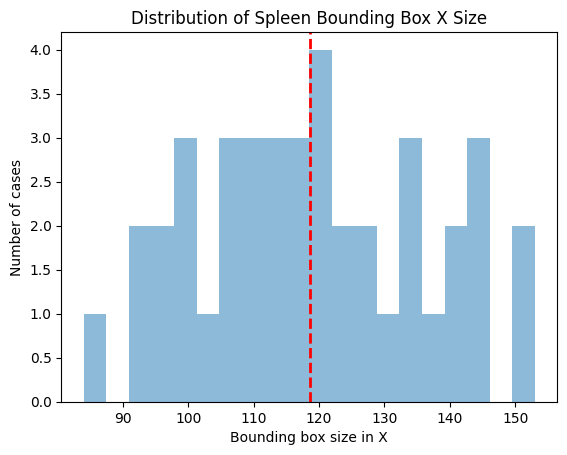

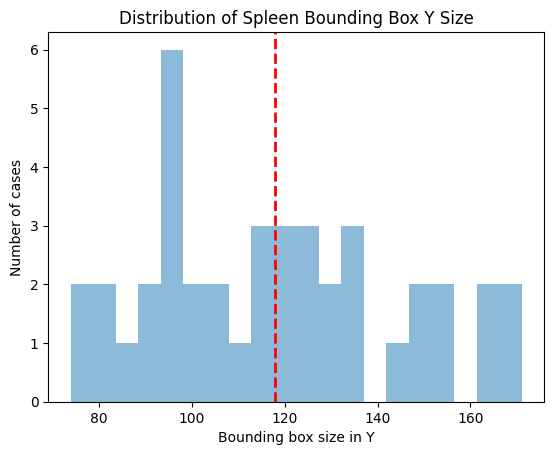

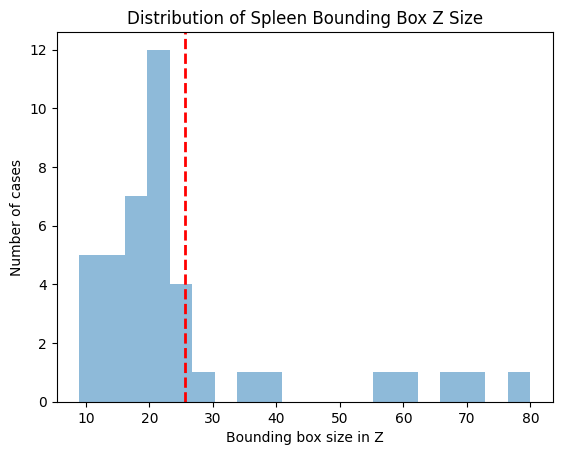

In [ ]:
# Plotting bounding box distributions
plt.hist(inspection_df['bbox_x_size'], bins=20, alpha=0.5, label='X')
plt.axvline(inspection_df['bbox_x_size'].mean(), color='r', linestyle='dashed', linewidth=2)
plt.xlabel('Bounding box size in X')
plt.ylabel('Number of cases')
plt.title('Distribution of Spleen Bounding Box X Size')
plt.show()

plt.hist(inspection_df['bbox_y_size'], bins=20, alpha=0.5, label='Y')
plt.axvline(inspection_df['bbox_y_size'].mean(), color='r', linestyle='dashed', linewidth=2)
plt.xlabel('Bounding box size in Y')
plt.ylabel('Number of cases')
plt.title('Distribution of Spleen Bounding Box Y Size')
plt.show()

plt.hist(inspection_df['bbox_z_size'], bins=20, alpha=0.5, label='Z')
plt.axvline(inspection_df['bbox_z_size'].mean(), color='r', linestyle='dashed', linewidth=2)
plt.xlabel('Bounding box size in Z')
plt.ylabel('Number of cases')
plt.title('Distribution of Spleen Bounding Box Z Size')
plt.show()

In [ ]:
# Computing recommended crop margins- to determinse what size contains >90% of spleens
inspection_df[
    ['bbox_x_size', 'bbox_y_size', 'bbox_z_size']
].quantile([0.5, 0.75, 0.9, 0.95, 1.0])


,bbox_x_size,bbox_y_size,bbox_z_size
0.50,118.0,115.0,21.0
0.75,133.0,135.0,25.0
0.90,144.0,156.0,58.0
0.95,145.0,166.0,69.0
1.00,153.0,171.0,80.0


This showed that most spleens are spatially wide in X/Y, and relatively thin in Z. There are a few outliers that extend much farther in Z.
This strongly support cropping, resampling, and patch-based training.
I will use a crop/patch size of 160 x 192 x 96. This will help conserve GPU memory and mitigate some poor foreground sampling.

In [ ]:
# Inspecting voxel spacing quantiles - This will help decide resampling strategy
inspection_df[
    ['image_spacing_x_mm', 'image_spacing_y_mm', 'image_spacing_z_mm']
].describe().T


,count,mean,std,min,25%,50%,75%,max
image_spacing_x_mm,41.0,0.812405,0.097809,0.613281,0.742188,0.792969,0.902344,0.976562
image_spacing_y_mm,41.0,0.812405,0.097809,0.613281,0.742188,0.792969,0.902344,0.976562
image_spacing_z_mm,41.0,4.368292,1.552808,1.500000,4.000000,5.000000,5.000000,8.000000


Shows strong anisotropy with high in-plane resolution (X/Y) and low through-plane resolution (Z).
I will utilize 1.5 x 1.5 x 2.0 mm resampling (conservative) rather than near-siotropic or preserve native Z.
This will educe anisotropy (more spatial cosistency), will be computationally efficient, and preserves meaningful anatomy.

In [ ]:
# Loading NIfTI volume
from scipy.ndimage import zoom

DATASET_DIR = Path('/content/drive/MyDrive/BME6720_Project/Task09_Spleen')
manifest_path = DATASET_DIR / 'week6dataset_merged_inspection.csv'
inspection_df = pd.read_csv(manifest_path)

PREPROCESSED_DIR = DATASET_DIR / 'preprocessed_npz'
PREPROCESSED_DIR.mkdir(exist_ok=True)

print('cases:', len(inspection_df))
print('Output folder:', PREPROCESSED_DIR)

cases: 41
Output folder: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/preprocessed_npz


In [ ]:
def load_nifti(image_path, label_path):
    image_nii = nib.load(str(image_path))
    label_nii = nib.load(str(label_path))

    image = image_nii.get_fdata(dtype=np.float32)
    label = label_nii.get_fdata().astype(np.uint8)

    spacing = tuple(float(x) for x in image_nii.header.get_zooms()[:3])
    return image, label, spacing

In [ ]:
row = inspection_df.iloc[0]

image, label, spacing = load_nifti(row["image_file"], row["label_file"])

print("spacing:", spacing)
print("type:", type(spacing))

spacing: (0.9765620231628418, 0.9765620231628418, 5.0)
type: <class 'tuple'>


In [ ]:
# Resampling image and label
import numpy as np
from scipy.ndimage import zoom

TARGET_SPACING = (1.5, 1.5, 2.0)

def resample_volume(volume, original_spacing, target_spacing, is_label=False):
    resize_factor = np.array(original_spacing) / np.array(target_spacing)
    new_shape = np.round(np.array(volume.shape) * resize_factor).astype(int)
    zoom_factor = new_shape / np.array(volume.shape)

    order = 0 if is_label else 1   # Nearest for label, linear for CT
    resampled = zoom(volume, zoom_factor, order=order)
    if is_label:
        resampled = (resampled > 0).astype(np.uint8)
    else:
        resampled = resampled.astype(np.float32)

    return resampled

In [ ]:
# Clipping HU Values
HU_MIN = -100
HU_MAX = 400    # this will emphasize soft tissue while suppressing air/bone outliers

def clip_hu(image, min_hu=HU_MIN, max_hu=HU_MAX):
    return np.clip(image, min_hu, max_hu)

In [ ]:
# Normalize Image
def normalize_image(image):
    mean = image.mean()
    std = image.std()

    if std == 0:
        return image - mean

    return (image - mean) / std
#

In [ ]:
# Foreground crop around spleen
CROP_SIZE = (160, 192, 96)

def get_bbox(mask):
    coords = np.where(mask > 0)
    if len(coords[0]) == 0:
        return None

    x_min, x_max = coords[0].min(), coords[0].max()
    y_min, y_max = coords[1].min(), coords[1].max()
    z_min, z_max = coords[2].min(), coords[2].max()

    return (x_min, x_max, y_min, y_max, z_min, z_max)

In [ ]:
def crop_or_pad_centered(image, label, crop_size=CROP_SIZE):
    bbox = get_bbox(label)
    if bbox is None:
        center = np.array(image.shape) // 2
    else:
        x_min, x_max, y_min, y_max, z_min, z_max = bbox
        center = np.array([
            (x_min + x_max) // 2,
            (y_min + y_max) // 2,
            (z_min + z_max) // 2,
        ])

    crop_size = np.array(crop_size)
    start = center - crop_size // 2
    end = start + crop_size

    pad_before = np.maximum(-start, 0)
    pad_after = np.maximum(end - np.array(image.shape), 0)

    image_padded = np.pad(
        image,
        [(pad_before[i], pad_after[i]) for i in range(3)],
        mode='constant',
        constant_values=0
    )

    label_padded = np.pad(
        label,
        [(pad_before[i], pad_after[i]) for i in range(3)],
        mode='constant',
        constant_values=0
    )

    start = start + pad_before
    end = start + crop_size

    cropped_image = image_padded[
        start[0]:end[0],
        start[1]:end[1],
        start[2]:end[2],
    ]
    cropped_label = label_padded[
        start[0]:end[0],
        start[1]:end[1],
        start[2]:end[2],
    ]

    return cropped_image, cropped_label

In [ ]:
print(np)
print(TARGET_SPACING)
print(type(TARGET_SPACING))

<module 'numpy' from '/usr/local/lib/python3.12/dist-packages/numpy/__init__.py'>
(1.5, 1.5, 2.0)
<class 'tuple'>


In [ ]:
# Running the full preprocessing loop
preprocess_rows = []
for _, row in tqdm(inspection_df.iterrows(), total=len(inspection_df)):

    case_id = row['case_id']
    image_path = row['image_file']
    label_path = row['label_file']

    # Load
    image, label, spacing = load_nifti(image_path, label_path)

    # Resample
    image_resampled = resample_volume(
        image,
        original_spacing=spacing,
        target_spacing=TARGET_SPACING,
        is_label=False
    )
    label_resampled = resample_volume(
        label,
        original_spacing=spacing,
        target_spacing=TARGET_SPACING,
        is_label=True
    )

    # Clip HU
    image_clipped = clip_hu(image_resampled)

    # Normalize
    image_normalized = normalize_image(image_clipped)

    # Crop around spleen
    image_crop, label_crop = crop_or_pad_centered(image_normalized, label_resampled, crop_size=CROP_SIZE)

    output_path = PREPROCESSED_DIR / f'{case_id}.npz'
    np.savez_compressed(
        output_path,
        image=image_crop.astype(np.float32),
        label=label_crop.astype(np.uint8),
    )

    preprocess_rows.append({
        'case_id': case_id,
        'original_shape': image.shape,
        'resampled_shape': image_resampled.shape,
        'final_crop_shape': image_crop.shape,
        'original_spacing': spacing,
        'target_spacing': TARGET_SPACING,
        'output_file': str(output_path),
        'spleen_voxels_after_crop': int(np.sum(label_crop > 0))

    })
preprocess_df = pd.DataFrame(preprocess_rows)
preprocess_df.head()

100%|██████████| 41/41 [05:57<00:00,  8.72s/it]


,case_id,original_shape,resampled_shape,final_crop_shape,original_spacing,target_spacing,output_file,spleen_voxels_after_crop
0,spleen_10,"(512, 512, 55)","(333, 333, 138)","(160, 192, 96)","(0.9765620231628418, 0.9765620231628418, 5.0)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,56656
1,spleen_12,"(512, 512, 168)","(257, 257, 126)","(160, 192, 96)","(0.7539060115814209, 0.7539060115814209, 1.5)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,100762
2,spleen_13,"(512, 512, 77)","(253, 253, 96)","(160, 192, 96)","(0.7421879768371582, 0.7421879768371582, 2.5)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,61719
3,spleen_14,"(512, 512, 54)","(291, 291, 135)","(160, 192, 96)","(0.8515620231628418, 0.8515620231628418, 5.0)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,100517
4,spleen_16,"(512, 512, 61)","(271, 271, 244)","(160, 192, 96)","(0.7929689884185791, 0.7929689884185791, 8.0)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,45225


In [ ]:
# Saving preprocessing summary
preprocess_summary_path = DATASET_DIR / 'week6dataset_preprocess_summary.csv'
preprocess_df.to_csv(preprocess_summary_path, index=False)
print('Preprocessing summary saved to:')
print(preprocess_summary_path)

Preprocessing summary saved to:
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/week6dataset_preprocess_summary.csv


In [ ]:
print(preprocess_df['final_crop_shape'].value_counts())

final_crop_shape
(160, 192, 96)    41
Name: count, dtype: int64


In [ ]:
print('Cases with spleen after crop:')
print((preprocess_df['spleen_voxels_after_crop'] > 0).sum(), '/', len(preprocess_df))

Cases with spleen after crop:
41 / 41


In [1]:
import torch
torch.cuda.is_available()

True

# Week 6 & 7

In [53]:
# Reloading preprocessing summay

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
from pathlib import Path

DATASET_DIR = Path('/content/drive/MyDrive/BME6720_Project/Task09_Spleen')
manifest_path = DATASET_DIR / 'week6dataset_preprocess_summary.csv'
preprocess_df = pd.read_csv(manifest_path)
print("Cases:", len(preprocess_df))
preprocess_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cases: 41


,case_id,original_shape,resampled_shape,final_crop_shape,original_spacing,target_spacing,output_file,spleen_voxels_after_crop
0,spleen_10,"(512, 512, 55)","(333, 333, 138)","(160, 192, 96)","(0.9765620231628418, 0.9765620231628418, 5.0)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,56656
1,spleen_12,"(512, 512, 168)","(257, 257, 126)","(160, 192, 96)","(0.7539060115814209, 0.7539060115814209, 1.5)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,100762
2,spleen_13,"(512, 512, 77)","(253, 253, 96)","(160, 192, 96)","(0.7421879768371582, 0.7421879768371582, 2.5)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,61719
3,spleen_14,"(512, 512, 54)","(291, 291, 135)","(160, 192, 96)","(0.8515620231628418, 0.8515620231628418, 5.0)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,100517
4,spleen_16,"(512, 512, 61)","(271, 271, 244)","(160, 192, 96)","(0.7929689884185791, 0.7929689884185791, 8.0)","(1.5, 1.5, 2.0)",/content/drive/MyDrive/BME6720_Project/Task09_...,45225


In [54]:
# Verifying that all files exist
preprocess_df['file_exists'] = preprocess_df['output_file'].apply(lambda x: Path(x).exists())
preprocess_df['file_exists'].value_counts()

print(preprocess_df['file_exists'].sum(),
      '/', len(preprocess_df)
)

41 / 41


In [55]:
# Loading a sample case
import numpy as np
sample_path = preprocess_df.iloc[0]['output_file']
sample = np.load(sample_path)

print(sample.files)

['image', 'label']


In [56]:
# Inspecting shapes
image = sample['image']
label = sample['label']

print('Image shape:', image.shape)
print('Label shape:', label.shape)

Image shape: (160, 192, 96)
Label shape: (160, 192, 96)


In [57]:
print(np.unique(label))

[0 1]


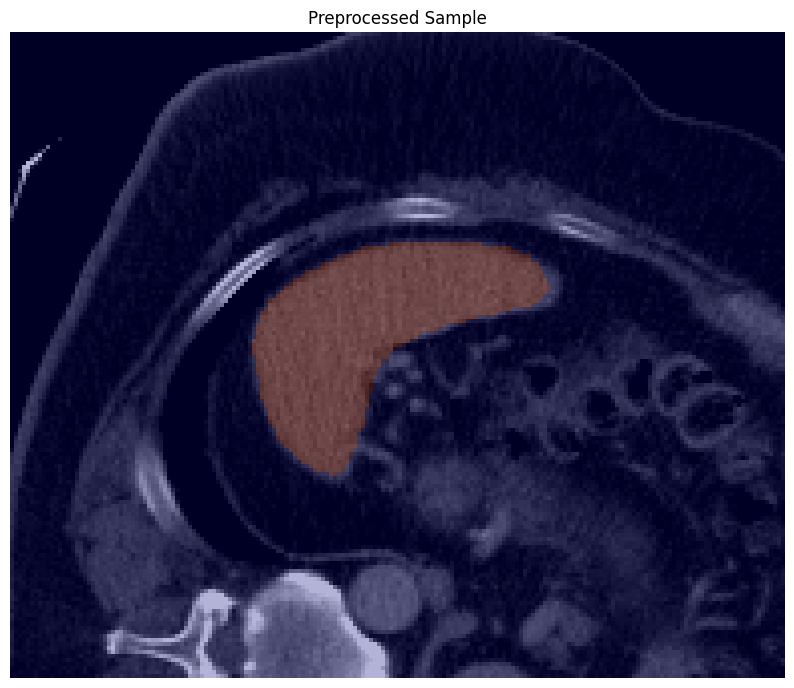

In [58]:
# Final visual sanity check
import matplotlib.pyplot as plt

mid_slice = image.shape[2] // 2

plt.figure(figsize=(10, 10))
plt.imshow(image[:, :, mid_slice], cmap='gray')
plt.imshow(label[:, :, mid_slice], cmap='jet', alpha=0.3)
plt.axis('off')
plt.title('Preprocessed Sample')
plt.show()

# Creating a reproducible train/validation split

In [13]:
# Creating a split
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    preprocess_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print('Training cases:', len(train_df))
print('Validation cases:', len(val_df))

Training cases: 32
Validation cases: 9


In [14]:
# Saving the split files
train_split_path = DATASET_DIR / 'train_split.csv'
val_split_path = DATASET_DIR / 'val_split.csv'

train_df.to_csv(train_split_path, index=False)
val_df.to_csv(val_split_path, index=False)

print('Train split saved to:', train_split_path)
print('Validation split saved to:', val_split_path)

Train split saved to: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/train_split.csv
Validation split saved to: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/val_split.csv


In [15]:
# Confirming no overlap
train_cases = set(train_df['case_id'])
val_cases = set(val_df['case_id'])

overlap = train_cases.intersection(val_cases)

print('Overlap between train and validation cases:', overlap)

Overlap between train and validation cases: set()


In [16]:
print('Train case IDs:')
print(sorted(train_cases))

print('\nValidation case IDs:')
print(sorted(val_cases))

Train case IDs:
['spleen_10', 'spleen_12', 'spleen_13', 'spleen_14', 'spleen_17', 'spleen_18', 'spleen_19', 'spleen_20', 'spleen_21', 'spleen_22', 'spleen_24', 'spleen_26', 'spleen_27', 'spleen_28', 'spleen_29', 'spleen_3', 'spleen_32', 'spleen_33', 'spleen_38', 'spleen_40', 'spleen_45', 'spleen_46', 'spleen_47', 'spleen_52', 'spleen_53', 'spleen_56', 'spleen_59', 'spleen_6', 'spleen_60', 'spleen_61', 'spleen_62', 'spleen_63']

Validation case IDs:
['spleen_16', 'spleen_2', 'spleen_25', 'spleen_31', 'spleen_41', 'spleen_44', 'spleen_49', 'spleen_8', 'spleen_9']


# Building the Pytorch Dataset and DataLoader

In [17]:
# Importing Pytorch and Defining Dataset Class
import torch
from torch.utils.data import Dataset, DataLoader

class SpleenNPZDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data = np.load(row['output_file'])
        image = data['image'].astype(np.float32)
        label = data['label'].astype(np.float32)

        image = np.expand_dims(image, axis=0)   #Adding channel dimension [C, H, W, D]
        label = np.expand_dims(label, axis=0)

        image = torch.from_numpy(image)
        label = torch.from_numpy(label)

        return {
            'image': image,
            'label': label,
            'case_id': row['case_id']
        }

In [18]:
# Creating Dataset
train_dataset = SpleenNPZDataset(train_df)
val_dataset = SpleenNPZDataset(val_df)

print('Train dataset size:', len(train_dataset))
print('Validation dataset size:', len(val_dataset))
#

Train dataset size: 32
Validation dataset size: 9


In [19]:
# Inspecting one sample
sample = train_dataset[0]
print('Image shape:', sample['image'].shape)
print('Label shape:', sample['label'].shape)
print('Case ID:', sample['case_id'])
print('Image dtype:', sample['image'].dtype)
print('Label dtype:', sample['label'].dtype)
print('Unique label values:', torch.unique(sample['label']))
#

Image shape: torch.Size([1, 160, 192, 96])
Label shape: torch.Size([1, 160, 192, 96])
Case ID: spleen_18
Image dtype: torch.float32
Label dtype: torch.float32
Unique label values: tensor([0., 1.])


In [20]:
# Creating DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [21]:
# Inspecting one batch
batch = next(iter(train_loader))
print('Batch image shape:', batch['image'].shape)
print('Batch label shape:', batch['label'].shape)
print('Batch case IDs:', batch['case_id'])
#

Batch image shape: torch.Size([2, 1, 160, 192, 96])
Batch label shape: torch.Size([2, 1, 160, 192, 96])
Batch case IDs: ['spleen_24', 'spleen_6']


In [22]:
# Data Augmentation- to reduce overfitting
!pip install monai -q
import monai
print(monai.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 100.7 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


1.5.2


In [23]:
# Creating tansform pipeline
from monai.transforms import (
    Compose,
    RandFlip,
    RandRotate90,
    RandShiftIntensity,
    RandScaleIntensity
)

train_transform = Compose([
    RandFlip(
        prob=0.5,
        spatial_axis=0
    ),
    RandFlip(
        prob=0.5,
        spatial_axis=1
    ),
    RandRotate90(
        prob=0.5,
        max_k=3
    ),
    RandShiftIntensity(
        offsets=0.1,
        prob=0.5
    ),
    RandScaleIntensity(
        prob=0.5,
        factors=0.1
    )
])

In [24]:
# Updating Dataset Class
class SpleenNPZDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data = np.load(row['output_file'])
        image = data['image'].astype(np.float32)
        label = data['label'].astype(np.float32)

        image = np.expand_dims(image, axis=0)
        label = np.expand_dims(label, axis=0)

        if self.transform:
            sample = {
                'image': image,
                'label': label
            }
            sample = self.transform(sample)
            image = sample['image']
            label = sample['label']

        image = torch.tensor(image)
        label = torch.tensor(label)

        return {
            'image': image,
            'label': label,
            'case_id': row['case_id']
        }

In [25]:
# Using Augmentation for training only
train_dataset = SpleenNPZDataset(train_df, transform=None)

val_dataset = SpleenNPZDataset(val_df, transform=None)



In [27]:
# Verifying DataLoader
sample = train_dataset[1]
print('Image shape:', sample['image'].shape)
print('Label shape:', sample['label'].shape)
print('Case ID:', sample['case_id'])
print('Unique Labels:', torch.unique(sample['label']))
#

Image shape: torch.Size([1, 160, 192, 96])
Label shape: torch.Size([1, 160, 192, 96])
Case ID: spleen_45
Unique Labels: tensor([0., 1.])


In [28]:
# Building Baseline 3d U-Net
import torch
from monai.networks.nets import UNet
from monai.losses import DiceLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name(0))

cuda
NVIDIA A100-SXM4-40GB


In [29]:
# Defining Baseline 3D U-Net
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
    num_res_units=2           #Intentionally conservative
).to(device)

print(model)

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

In [31]:
# Define loss function and Optimizer
loss_function = DiceLoss(
    sigmoid=True
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [32]:
# Doing a single forward pass test
batch = next(iter(train_loader))

images = batch['image'].to(device)
labels = batch['label'].to(device)

print(images.shape)
print(labels.shape)



torch.Size([2, 1, 160, 192, 96])
torch.Size([2, 1, 160, 192, 96])


In [34]:
outputs = model(images)
print(outputs.shape)

torch.Size([2, 1, 160, 192, 96])


In [36]:
# Compute loss
loss = loss_function(outputs, labels)
print('Dice Loss:', loss.item())
#

Dice Loss: 0.9872198104858398


The Dice Loss shows that the model currently has no overlap which is expected before training

In [37]:
# Backward pass test and memory check
optimizer.zero_grad()
loss.backward()
optimizer.step()
print('Optimization step successful')
#

print(f'Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB')
print(f'Reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB')
#

Optimization step successful
Allocated: 0.08 GB
Reserved: 1.97 GB


In [38]:
# Short Training Loop
num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, - Training Loss: {avg_loss:.4f}')
#

Epoch 1/5, - Training Loss: 0.9624
Epoch 2/5, - Training Loss: 0.9563
Epoch 3/5, - Training Loss: 0.9522
Epoch 4/5, - Training Loss: 0.9500
Epoch 5/5, - Training Loss: 0.9489


This showed that the model is learning as my loss decreased consistently. I will add valiadtion Dice for the next iteration so I can track how well the model generalizes

In [39]:
# Adding validation Dice
from monai.metrics import DiceMetric
from monai.transforms import Activations, AsDiscrete

dice_metric = DiceMetric(
    include_background=True,
    reduction='mean'
)
post_pred = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5)
])
post_label = AsDiscrete(threshold=0.5)
#

In [44]:
# Updating Training loop to include validation Dice
num_epochs = 25

train_losses = []
val_dice_scores = []
best_val_dice = -1
best_model_path = DATASET_DIR / 'best_baseline_unet.pth'

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    dice_metric.reset()

    with torch.no_grad():
        for vbatch in val_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images)
            preds = post_pred(outputs)
            labels_post = post_label(labels)

            dice_metric(y_pred=preds, y=labels_post)

        val_dice = dice_metric.aggregate().item()
        dice_metric.reset()

        val_dice_scores.append(val_dice)
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), best_model_path)
            print(f'New best model saved with Val Dice: {best_val_dice:.4f}')

    print(f'Epoch {epoch+1}/{num_epochs}, - Training Loss: {avg_train_loss:.4f}, Validation Dice: {val_dice:.4f}')
#

New best model saved with Val Dice: 0.6549
Epoch 1/25, - Training Loss: 0.9271, Validation Dice: 0.6549
Epoch 2/25, - Training Loss: 0.9269, Validation Dice: 0.5699
New best model saved with Val Dice: 0.7159
Epoch 3/25, - Training Loss: 0.9268, Validation Dice: 0.7159
New best model saved with Val Dice: 0.7431
Epoch 4/25, - Training Loss: 0.9266, Validation Dice: 0.7431
Epoch 5/25, - Training Loss: 0.9265, Validation Dice: 0.4354
Epoch 6/25, - Training Loss: 0.9264, Validation Dice: 0.6293
Epoch 7/25, - Training Loss: 0.9263, Validation Dice: 0.4728
Epoch 8/25, - Training Loss: 0.9261, Validation Dice: 0.4800
Epoch 9/25, - Training Loss: 0.9260, Validation Dice: 0.5802
New best model saved with Val Dice: 0.7981
Epoch 10/25, - Training Loss: 0.9259, Validation Dice: 0.7981
Epoch 11/25, - Training Loss: 0.9258, Validation Dice: 0.5091
Epoch 12/25, - Training Loss: 0.9257, Validation Dice: 0.5242
Epoch 13/25, - Training Loss: 0.9255, Validation Dice: 0.4538
Epoch 14/25, - Training Loss: 0

Baseline 3D U-Net
Best Val Dice: 0.8283
Best Epoch: 24
Loss: Dice Loss
Target spacing: 1.5 × 1.5 × 2.0 mm
Crop size: 160 × 192 × 96

Next, I will evaluate the saved best model qualitatively to ensure appropriateness

In [45]:
# Reloading Model checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
    num_res_units=2
).to(device)

best_model_path = DATASET_DIR / 'best_baseline_unet.pth'
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print('Model loaded successfully')
#

Model loaded successfully


In [46]:
# Defining prediction function
def predict_case(model, image_tensor, threshold=0.5):
    model.eval()

    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        logits = model(image_tensor)
        probs = torch.sigmoid(logits)
        pred = (probs > threshold).float()

    return pred.squeeze(0).cpu().numpy()
#

In [47]:
# Define Dice function
def dice_score(pred, label, eps=1e-8):
    pred = pred > 0
    label = label > 0

    intersection = np.sum(pred & label)
    denominator = np.sum(pred) + np.sum(label)

    if denominator == 0:
        return 1.0
    return (2.0 * intersection + eps)/ (denominator + eps)
#

In [49]:
# Evaluating all Validation cases
val_results = []

for i in range(len(val_dataset)):
    sample = val_dataset[i]
    image = sample['image']
    label = sample['label'].squeeze().numpy()
    case_id = sample['case_id']

    pred = predict_case(model, image)
    dice = dice_score(pred, label)

    val_results.append({
        'case_id': case_id,
        'dice': dice,
        'gt_voxels': int(np.sum(label > 0)),
        'pred_voxels': int(np.sum(pred > 0))
    })

val_results_df = pd.DataFrame(val_results)
val_results_df.sort_values(by='dice', ascending=False)
print(val_results_df)
#

     case_id      dice  gt_voxels  pred_voxels
0  spleen_41  0.625281      41958        92065
1  spleen_25  0.526743      23124        64676
2   spleen_2  0.808061      68319       100693
3  spleen_44  0.488504      26255        79132
4  spleen_16  0.714152      45225        80006
5   spleen_9  0.781119      60753        92307
6  spleen_31  0.817358      79755       113651
7   spleen_8  0.874175     113349       133757
8  spleen_49  0.758340      67252       107667


In [50]:
# Saving validation results
val_results_path = DATASET_DIR / 'baseline_validation_case_results.csv'
val_results_df.to_csv(val_results_path, index=False)

print('Validation results saved:')
print(val_results_path)

Validation results saved:
/content/drive/MyDrive/BME6720_Project/Task09_Spleen/baseline_validation_case_results.csv


In [62]:
# Visualizing one validation case
import matplotlib.pyplot as plt
def visualize_prediction(image, label, pred, case_id=None, slice_idx=None):
    image = np.asarray(image)
    label = np.asarray(label)
    pred = np.asarray(pred)

    image = np.squeeze(image)   # Remoing channel/batch singleton dimensions
    label = np.squeeze(label)
    pred = np.squeeze(pred)

    print('Image shape after squeeze:', image.shape)
    print('Label shape after squeeze:', label.shape)
    print('Pred shape after squeeze:', pred.shape)

    if slice_idx is None:
        mask_slices = np.where(np.sum(label > 0, axis=(0, 1)) > 0)[0]
        if len(mask_slices) > 0:
            slice_idx = mask_slices[len(mask_slices) // 2]
        else:
            slice_idx = image.shape[2] // 2

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image[:, :, slice_idx], cmap='gray')
    plt.title('CT Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(image[:, :, slice_idx], cmap='gray')
    plt.imshow(label[:, :, slice_idx], alpha=0.3, cmap='Reds')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(image[:, :, slice_idx], cmap='gray')
    plt.imshow(pred[:, :, slice_idx], alpha=0.3, cmap='Blues')
    plt.title('Prediction')
    plt.axis('off')

    if case_id:
        plt.suptitle(f'Case ID: {case_id} | Slice: {slice_idx}')

    plt.show()

Image shape after squeeze: (160, 192, 96)
Label shape after squeeze: (160, 192, 96)
Pred shape after squeeze: (160, 192, 96)


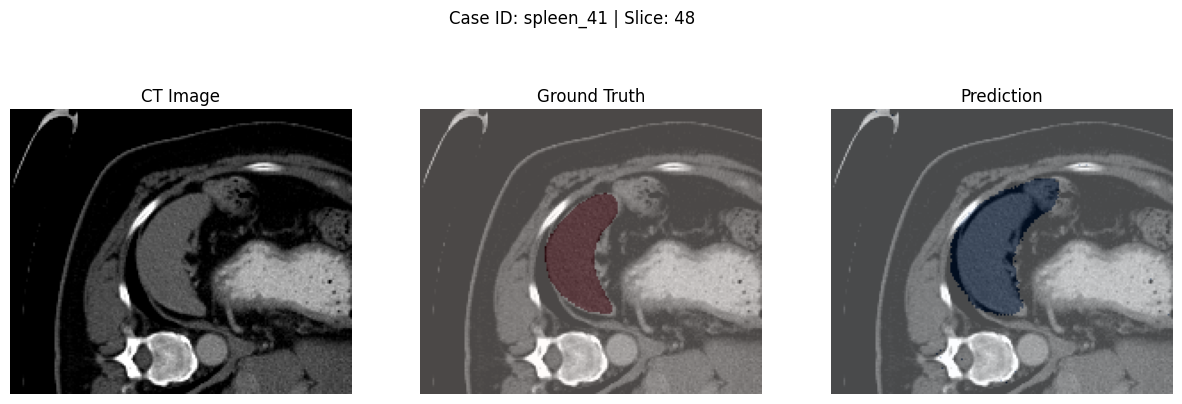

In [63]:
# Calling the function
sample = val_dataset[0]
image = sample['image']
label = sample['label']
case_id = sample['case_id']
pred = predict_case(model, image)

visualize_prediction(
    image=image,
    label=label,
    pred=pred,
    case_id=case_id
)
#

In [64]:
# Visualizing best, median and worst cases
sorted_results = val_results_df.sort_values('dice', ascending=False).reset_index(drop=True)

best_case = sorted_results.iloc[0]['case_id']
median_case = sorted_results.iloc[len(sorted_results) // 2]['case_id']
worst_case = sorted_results.iloc[-1]['case_id']

print('Best Case:', best_case)
print('Median Case:', median_case)
print('Worst Case:', worst_case)

Best Case: spleen_8
Median Case: spleen_49
Worst Case: spleen_44


In [65]:
def get_sample_by_case_id(case_id, dataset):
    for i in range(len(dataset)):
        sample = dataset[i]
        if sample['case_id'] == case_id:
            return sample
    raise ValueError(f'Case ID {case_id} not found in the dataset')

Image shape after squeeze: (160, 192, 96)
Label shape after squeeze: (160, 192, 96)
Pred shape after squeeze: (160, 192, 96)


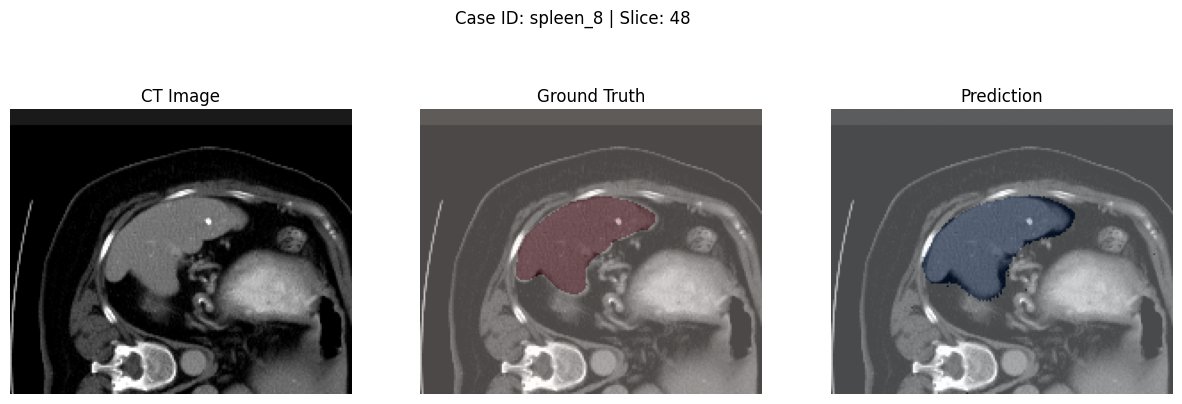

Image shape after squeeze: (160, 192, 96)
Label shape after squeeze: (160, 192, 96)
Pred shape after squeeze: (160, 192, 96)


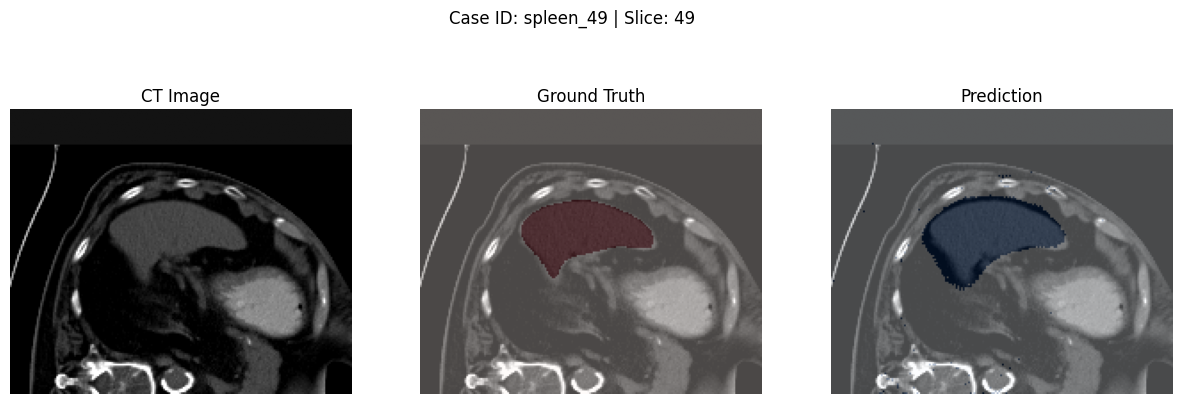

Image shape after squeeze: (160, 192, 96)
Label shape after squeeze: (160, 192, 96)
Pred shape after squeeze: (160, 192, 96)


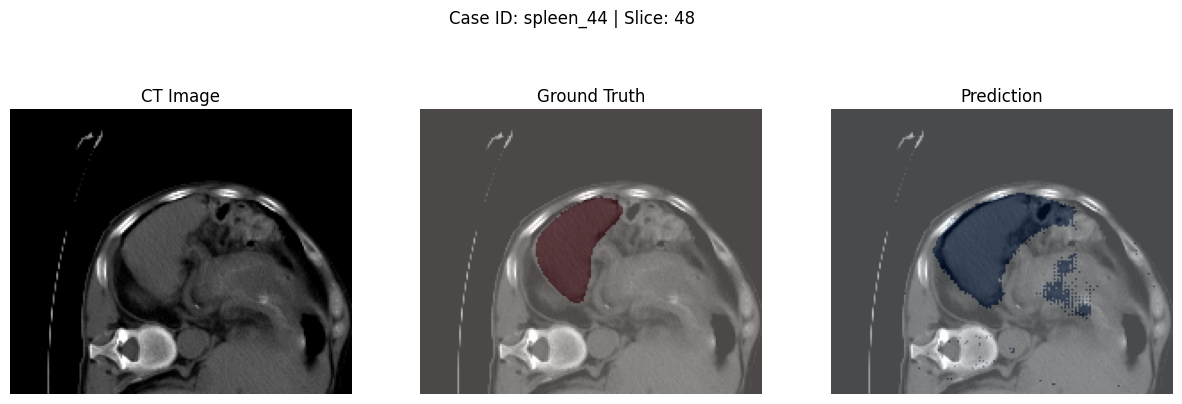

In [66]:
for case_id in [best_case, median_case, worst_case]:
    sample = get_sample_by_case_id(case_id, val_dataset)

    image = sample['image']
    label = sample['label']
    pred = predict_case(model, image)

    visualize_prediction(
        image=image,
        label=label,
        pred=pred,
        case_id=case_id
    )
#

These show:
The largest errors occur near organ boundaries.
Predictions are generally correct globally.
Most discrepancies occur where tissue contrast is limited.

The bottleneck for my model seems to be boundary precision rather than localization.

Next steps will be to finalize trraining targets

In [69]:
# Creating Dice + CE ablation by reinitiating model from scratch
from monai.losses import DiceCELoss

model_dicece = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
    num_res_units=2
).to(device)

loss_function_dicece = DiceCELoss(
    sigmoid=True,
)

optimizer_dicece = torch.optim.Adam(
    model_dicece.parameters(),
    lr=1e-4
)

best_val_dice_dicece = -1
best_model_path_dicece = DATASET_DIR / 'best_dicece_unet.pth'

dicece_train_losses = []
dicece_val_scores = []

#

In [70]:
# Training
num_epochs = 25
for epoch in range(num_epochs):
    model_dicece.train()
    epoch_loss = 0

    for batch in train_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer_dicece.zero_grad()

        outputs = model_dicece(images)
        loss = loss_function_dicece(outputs, labels)

        loss.backward()
        optimizer_dicece.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    dicece_train_losses.append(avg_train_loss)

    # Validation
    model_dicece.eval()
    dice_metric.reset()

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model_dicece(images)
            preds = post_pred(outputs)
            labels_post = post_label(labels)

            dice_metric(y_pred=preds, y=labels_post)

    val_dice = dice_metric.aggregate().item()
    dice_metric.reset()

    dicece_val_scores.append(val_dice)

    if val_dice > best_val_dice_dicece:
        best_val_dice_dicece = val_dice
        torch.save(model_dicece.state_dict(), best_model_path_dicece)
        print(f'New best DiceCE model saved with Val Dice: {best_val_dice_dicece:.4f}')

    print(
        f'Epoch {epoch+1}/{num_epochs}'
        f'- Training Loss: {avg_train_loss:.4f}'
        f'- Validation Dice: {val_dice:.4f}'

    )

New best DiceCE model saved with Val Dice: 0.0461
Epoch 1/25- Training Loss: 1.8940- Validation Dice: 0.0461
New best DiceCE model saved with Val Dice: 0.0539
Epoch 2/25- Training Loss: 1.7960- Validation Dice: 0.0539
New best DiceCE model saved with Val Dice: 0.0662
Epoch 3/25- Training Loss: 1.7389- Validation Dice: 0.0662
New best DiceCE model saved with Val Dice: 0.0746
Epoch 4/25- Training Loss: 1.7056- Validation Dice: 0.0746
New best DiceCE model saved with Val Dice: 0.0800
Epoch 5/25- Training Loss: 1.6860- Validation Dice: 0.0800
New best DiceCE model saved with Val Dice: 0.0893
Epoch 6/25- Training Loss: 1.6737- Validation Dice: 0.0893
New best DiceCE model saved with Val Dice: 0.0971
Epoch 7/25- Training Loss: 1.6647- Validation Dice: 0.0971
New best DiceCE model saved with Val Dice: 0.1046
Epoch 8/25- Training Loss: 1.6578- Validation Dice: 0.1046
New best DiceCE model saved with Val Dice: 0.1140
Epoch 9/25- Training Loss: 1.6519- Validation Dice: 0.1140
New best DiceCE mod

In [71]:
# Saving logs
dicece_log_df = pd.DataFrame({
    'Epoch': range(1, num_epochs+1),
    'Training Loss': dicece_train_losses,
    'Validation Dice': dicece_val_scores
})

dicece_log_path = DATASET_DIR / 'dicece_training_log.csv'
dicece_log_df.to_csv(dicece_log_path, index=False)

print('Best DiceCE Val Dice:', best_val_dice_dicece)
print('DiceCE Log saved:', dicece_log_path)

Best DiceCE Val Dice: 0.6647871732711792
DiceCE Log saved: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/dicece_training_log.csv


Dice Loss performed better than DiceCE in my dataset, likely due to spleen voxels been extremely rare, and Dice Loss diectly optimizing overlap compared to DiceCE that may be more sensitive to background dominance

In [72]:
# Saving Dice baseline
dice_log_df = pd.DataFrame({
    'Epoch': range(1, num_epochs+1),
    'Training Loss': train_losses,
    'Validation Dice': val_dice_scores
})

dice_log_path = DATASET_DIR / 'dice_training_log.csv'
dice_log_df.to_csv(dice_log_path, index=False)

print('Best Dice Val:', best_val_dice)
print('Dice Log saved:', dice_log_path)

Best Dice Val: 0.8283270001411438
Dice Log saved: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/dice_training_log.csv


In [73]:
# Creating and saving a simple comparison table
comparison_df = pd.DataFrame({
    'Experiment': ['Dice Loss', 'Dice Loss + CE'],
    'Best Val Dice': [best_val_dice, best_val_dice_dicece],
    'Model': ['3D U-Net', '3D U-Net'],
    'Epochs': [25, 25],
    'Target_spacing': ['1.5 x 1.5 x 2.0 mm', '1.5 x 1.5 2.0 mm'],
    'Crop_size': ['160 x 192 x 96', '160 x 192 96']
})

comparison_path = DATASET_DIR / 'baseline_loss_ablation_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)

print('Comparison table saved:', comparison_path)

Comparison table saved: /content/drive/MyDrive/BME6720_Project/Task09_Spleen/baseline_loss_ablation_comparison.csv
